# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [36]:
# TODO: Import all necessary libraries here
import numpy as np              # For numerical operations and arrays
import pandas as pd             # For working with tabular data
import matplotlib.pyplot as plt # For plotting graphs
import seaborn as sns           # For advanced data visualization


from sklearn.model_selection import train_test_split    # Train test split utility
from sklearn.linear_model import LinearRegression       # Multiple Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Evaluation metrics
from sklearn.preprocessing import PolynomialFeatures    # For generating polynomial features
from sklearn.pipeline import Pipeline                   # For chaining preprocessing and model

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Configure matplotlib for slightly nicer default plots
# plt.rcParams['figure.figsize'] = (10, 8)
# plt.rcParams['axes.grid'] = True



# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)- ok
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
# TODO: Load regression dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI ML with phitron/Course 02: ML/assignment 3_December_2025/insurance.csv")

# shape and column names
print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo: Column names and types\n")
print(df.info())

# target variable
# charges is the Target variable
y=df["charges"]
print(y.shape)

Shape of dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Info: Column names and types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
(1338,)


#### Note:
- charges is the Target variable

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)-ok
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)



Describe (numeric columns):


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



After encoding



,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


(1338, 12)

correlation heatmap:



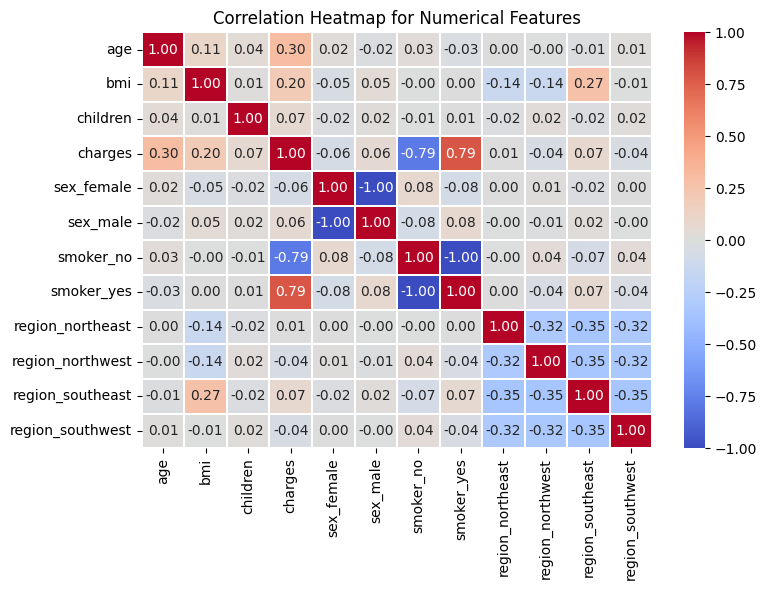

,charges
charges,1.000000
smoker_yes,0.787251
age,0.299008
bmi,0.198341
region_southeast,0.073982
children,0.067998
sex_male,0.057292
region_northeast,0.006349
region_northwest,-0.039905
region_southwest,-0.043210


In [39]:
# TODO: Perform EDA

# descriptive stat
print("\nDescribe (numeric columns):")
display(df.describe())

# correlation heatmap- need encoding

# encoding-one hot
print("\nAfter encoding\n")
cat_cols = ['sex', 'smoker','region']
df_enc = pd.get_dummies(df, columns=cat_cols, dtype=int)
display(df_enc.head(5))
print(df_enc.shape)

print("\ncorrelation heatmap:\n")
# numeric_cols=["age", "purchases"]
# target_col="premium_user"
corr_matrix = df_enc.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",fmt=".2f", linewidths=0.1)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

display(corr_matrix["charges"].sort_values(ascending=False))

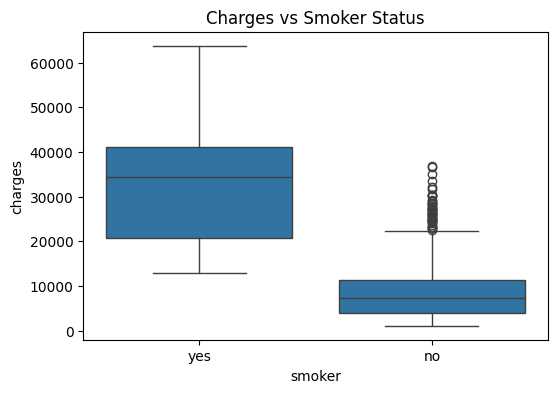

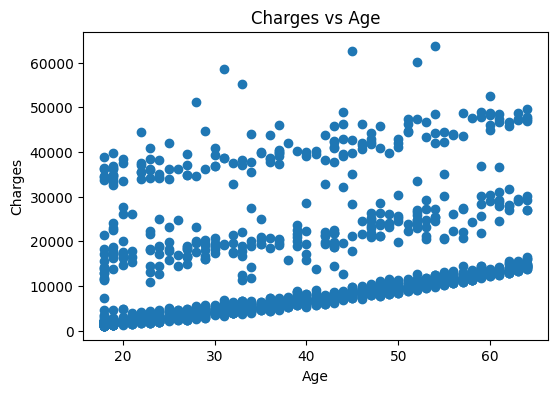

In [40]:
# Plot at least one feature vs targe

# smoker vs charges

plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df) # using original dataset
plt.title('Charges vs Smoker Status')
plt.show()

# age vs charges

plt.figure(figsize=(6,4))
plt.scatter(df['age'], df['charges'])
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Charges vs Age')
plt.show()

## TODO A3: Feature Preparation (5 Marks)-ok
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [41]:
print(df_enc.shape)
# df_enc.head()

(1338, 12)


In [42]:
# TODO: Prepare features
X=df_enc.drop("charges", axis=1)
y=df_enc["charges"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape: ", X_train.shape)
print("Test set shape: ", X_test.shape)

# print(X_train_scaled)
# print(X_test_scaled)

Training set shape:  (1070, 11)
Test set shape:  (268, 11)


In [43]:
# print(X_train_scaled)

#### Note:
- As all data are not in the same scale, scalling is necessary. specially, "charges" variable has very high values.

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [44]:
# TODO: Multiple Linear Regression

# train model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Inspect coefficients and intercept - extra
print('Intercept (bias term): ', lin_reg.intercept_)
print('\nCoefficients: ')
for feature_name, coef in zip(X, lin_reg.coef_):
  print(f'{feature_name}: {coef}')

# evaluations


Intercept (bias term):  13346.089736364485

Coefficients: 
age: 3614.975414828
bmi: 2036.228122896721
children: 516.8902471991536
sex_female: 4.646550537201325
sex_male: -4.646550537201538
smoker_no: -4779.240704458371
smoker_yes: 4779.24070445837
region_northeast: 199.69805793693294
region_northwest: 38.734949017436456
region_southeast: -86.62114742556237
region_southwest: -150.167101155828


In [45]:
# Evaluate using RMSE, MAE, R²

y_pred_lin = lin_reg.predict(X_test_scaled)

# metrics
mae_lin = mean_absolute_error(y_test, y_pred_lin) #(actual, precited)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f'MAE: {mae_lin}')
print(f'MSE: {mse_lin}')
print(f'RMSE: {rmse_lin}')
print(f'R²: {r2_lin}')

MAE: 4181.194473753653
MSE: 33596915.85136148
RMSE: 5796.284659276275
R²: 0.7835929767120722


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [46]:
# print(X_train_scaled)
# print(X_test_scaled)

In [47]:
# TODO: Polynomial Regression

degrees= [1,2,3,4, 5]
results = []

for degree in degrees:
  model=Pipeline([
      ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
      ("lin_reg", LinearRegression())
  ])

  model.fit(X_train_scaled, y_train)

  y_pred_poly = model.predict(X_test_scaled)

  mae_poly = mean_absolute_error(y_test, y_pred_poly)
  mse_poly = mean_squared_error(y_test, y_pred_poly)
  rmse_poly = np.sqrt(mse_poly)
  r2_poly = r2_score(y_test, y_pred_poly)

  results.append({
      "degree": degree,
      "mae": mae_poly,
      "mse": mse_poly,
      "rmse": rmse_poly,
      "r2": r2_poly
  })

results_df = pd.DataFrame(results)
results_df

,degree,mae,mse,rmse,r2
0,1,4181.194474,3.359692e+07,5796.284659,0.783593
1,2,2729.500134,2.071281e+07,4551.132385,0.866583
2,3,2937.918593,2.349822e+07,4847.496055,0.848641
3,4,3529.077571,3.815850e+07,6177.256538,0.754211
4,5,5511.901796,1.961750e+08,14006.247327,-0.263617


#### Note:
- Polynomial regression (degree 2) significantly improves performance over linear regression, because it gives lower MAE, MSE and RMSE and a higher R². Although not very satisfactory performance.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [48]:
# TODO: Support Vector Regression

# Train SVR (RBF kernel)
svr_rbf = SVR(kernel='rbf', C=1, gamma = 'scale')
svr_rbf.fit(X_train_scaled, y_train)

y_pred_svr = svr_rbf.predict(X_test_scaled)

# metrics
mae_svr = mean_absolute_error(y_test, y_pred_svr) #(actual, precited)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(f'MAE: {mae_svr}')
print(f'MSE: {mse_svr}')
print(f'RMSE: {rmse_svr}')
print(f'R²: {r2_svr}')


MAE: 8611.415551847522
MSE: 165952201.83549592
RMSE: 12882.243664653139
R²: -0.06894401159271046


#### Note:
- RBF carnel is used when there is non linear relationship between features.
- very poor performance compared to other regression models. large c improves the result such as c=500, but that may cause overfit.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [49]:
# # TODO: Prepare features
# X=df_enc.drop("charges", axis=1)
# y=df_enc["charges"]

# # Train test split and scaling
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Scaling
# # from sklearn.preprocessing import RobustScaler
# scaler =StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print("Training set shape: ", X_train.shape)
# print("Test set shape: ", X_test.shape)

# # print(X_train_scaled)
# # print(X_test_scaled)

In [50]:
# TODO: Random Forest Regressor

# Train Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train)

# Evaluate model
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

# metrics
mae_rf_reg = mean_absolute_error(y_test, y_pred_rf_reg) #(actual, precited)
mse_rf_reg = mean_squared_error(y_test, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg= r2_score(y_test, y_pred_rf_reg)

print(f'MAE: {mae_rf_reg}')
print(f'MSE: {mse_rf_reg}')
print(f'RMSE: {rmse_rf_reg}')
print(f'R²: {r2_rf_reg}')


MAE: 2541.614593844528
MSE: 21003637.60876614
RMSE: 4582.9725734250405
R²: 0.8647097634425496


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks) - ok
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [51]:
# TODO: Load classification dataset

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI ML with phitron/Course 02: ML/assignment 3_December_2025/loan_data.csv")

# shape and column names
print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

# Show class distribution - Comment on imbalance
df['loan_status'].value_counts(normalize=True)

Shape of dataset: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on

,proportion
loan_status,
0,0.777778
1,0.222222


#### Note:
- target class has class imbalance. loan rejection is about 78%, and approval about 22%

## TODO B2: Exploratory Data Analysis (5 Marks) - ok
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


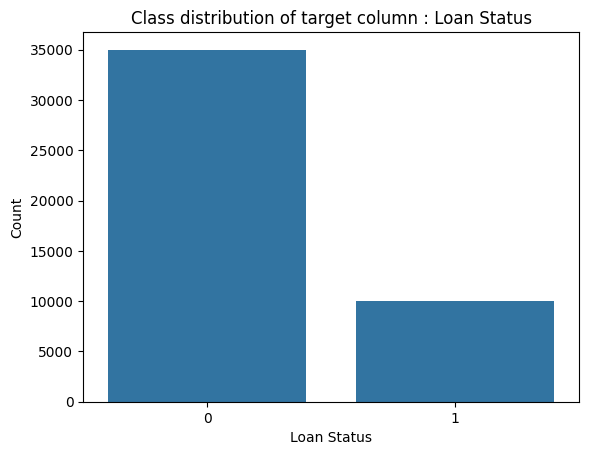

<Figure size 600x400 with 0 Axes>

In [52]:
# TODO: Classification EDA

sns.countplot(x='loan_status', data=df)
plt.title('Class distribution of target column : Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.figure(figsize=(6,4))
plt.show()


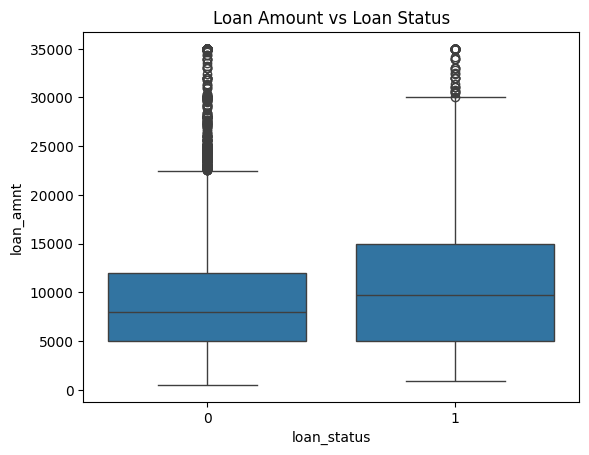

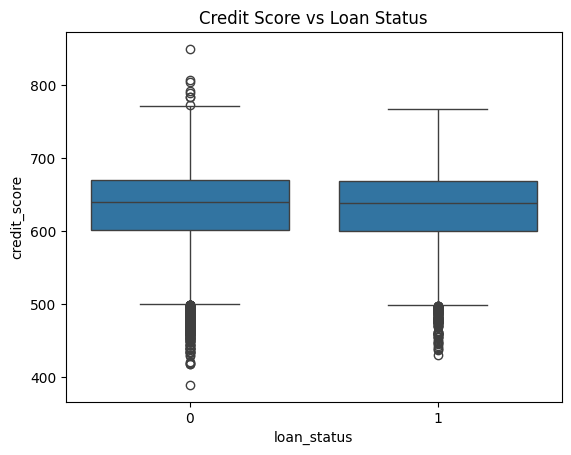

In [53]:
# Plot at least one feature vs class

# loan amount vs loan status
sns.boxplot(x='loan_status', y='loan_amnt', data=df)
plt.title('Loan Amount vs Loan Status')
plt.show()

# loan amount vs loan status
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title('Credit Score vs Loan Status')
plt.show()

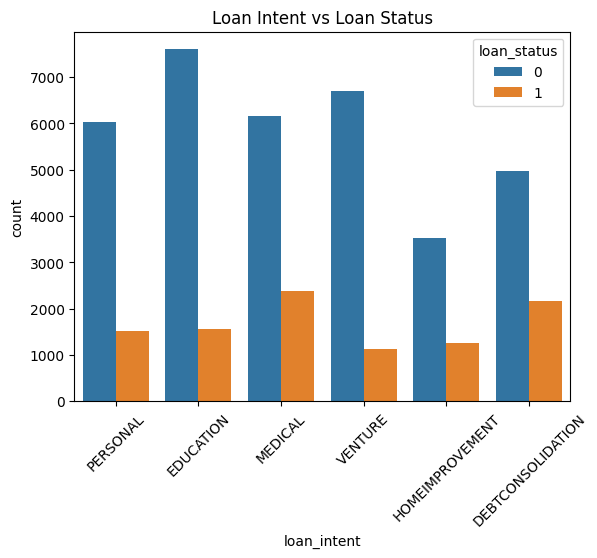

In [54]:
# loan intenst vs loan status
sns.countplot(x='loan_intent', hue='loan_status', data=df)
plt.xticks(rotation=45)
plt.title('Loan Intent vs Loan Status')
plt.show()

## TODO B3: Feature Preparation (5 Marks) - ok
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [55]:
# df.head()

In [56]:
# TODO: Prepare classification features

# Encoding (needed)
cat_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
df_enc = pd.get_dummies(df, columns=cat_cols, dtype=int)
# df_enc.head()

In [57]:
# split then Scaling

# num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

X=df_enc.drop("loan_status", axis=1)
y=df_enc["loan_status"]

# Train test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape: ", X_train.shape)
print("Test set shape: ", X_test.shape)

Training set shape:  (36000, 27)
Test set shape:  (9000, 27)


## TODO B4: Logistic Regression with L2 (8 Marks) - ok
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


Accuracy : 0.8996666666666666
Precision: 0.7891407485503427
Recall   : 0.7485


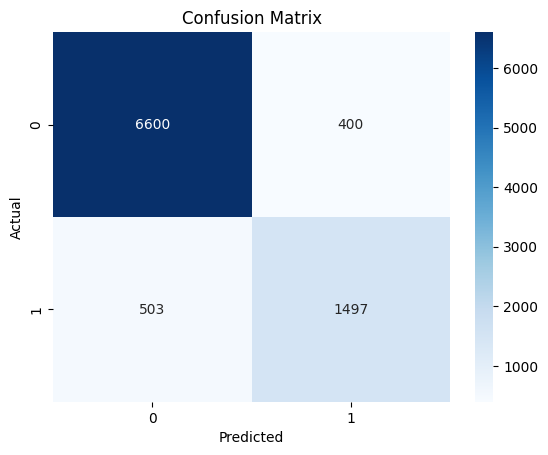

In [58]:
# TODO: Logistic Regression

# Train logistic regression on the scaled data
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Evaluate using Accuracy, Precision, Recall
y_pred = log_reg.predict(X_test_scaled)

accuracy_log_reg = accuracy_score(y_test, y_pred)
precision_log_reg = precision_score(y_test, y_pred)
recall_log_reg = recall_score(y_test, y_pred)

print("Accuracy :", accuracy_log_reg)
print("Precision:", precision_log_reg)
print("Recall   :", recall_log_reg)

# Show Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred)

sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## TODO B5: Support Vector Machine (7 Marks) - ok
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [59]:
# TODO: SVM Classification - Linear

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_svm_ln = svm_linear.predict(X_test_scaled)

# evaluate
accuracy_svm_ln = accuracy_score(y_test, y_pred_svm_ln)
precision_svm_ln = precision_score(y_test, y_pred_svm_ln)
recall_svm_ln = recall_score(y_test, y_pred_svm_ln)

print("Accuracy :", accuracy_svm_ln)
print("Precision:", precision_svm_ln)
print("Recall   :", recall_svm_ln)

Accuracy : 0.9004444444444445
Precision: 0.7939297124600639
Recall   : 0.7455


In [60]:
# SVM Classification - RBF

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test_scaled)

# evaluate
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
precision_svm_rbf = precision_score(y_test, y_pred_svm_rbf)
recall_svm_rbf = recall_score(y_test, y_pred_svm_rbf)

print("Accuracy :", accuracy_svm_rbf)
print("Precision:", precision_svm_rbf)
print("Recall   :", recall_svm_rbf)

Accuracy : 0.9154444444444444
Precision: 0.846670397313934
Recall   : 0.7565


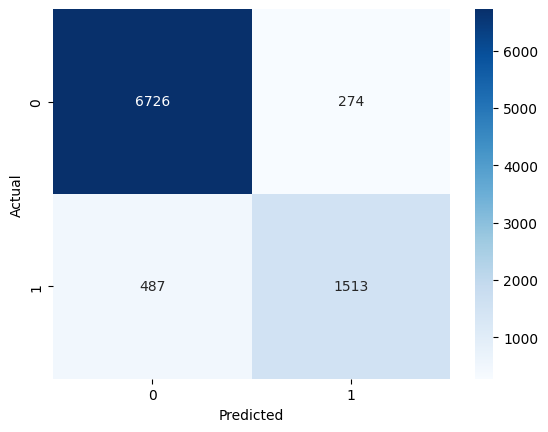

In [61]:
# confusion matrix for SVM Classification - RBF
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)

sns.heatmap(cm_svm_rbf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Note:
- svm_rbf performs better than svm_linear for this dataset.

## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [62]:
# TODO: Naive Bayes

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

# evaluate
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)
print("\nConfusion matrix:\n",cm)

Accuracy : 0.7348888888888889
Precision: 0.4559561843906892
Recall   : 0.999

Confusion matrix:
 [[4616 2384]
 [   2 1998]]


#### Note:
- choice: Gaussian Naive Bayes becasue this dataset contains continuous numerical features.
- very poor performance compared to other clf models.

## TODO B7: K-Nearest Neighbors (5 Marks) - ok
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [63]:
# TODO: KNN
k_values = range(10, 50)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2 ) # p=2= Euclidean distance

    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print(accuracies)

[0.8957777777777778, 0.8988888888888888, 0.8953333333333333, 0.899, 0.8948888888888888, 0.8971111111111111, 0.8954444444444445, 0.897, 0.8971111111111111, 0.8978888888888888, 0.8981111111111111, 0.8988888888888888, 0.897, 0.8982222222222223, 0.8971111111111111, 0.8995555555555556, 0.8985555555555556, 0.8985555555555556, 0.8988888888888888, 0.9, 0.8981111111111111, 0.8984444444444445, 0.8961111111111111, 0.8963333333333333, 0.8947777777777778, 0.8955555555555555, 0.8944444444444445, 0.8958888888888888, 0.8937777777777778, 0.8954444444444445, 0.893, 0.895, 0.8921111111111111, 0.8938888888888888, 0.891, 0.8936666666666667, 0.8918888888888888, 0.8925555555555555, 0.8911111111111111, 0.8922222222222222]


In [64]:
best_k = list(k_values)[int(np.argmax(accuracies))]
print("Best K:", best_k)
print("Best accuracy:", float(np.max(accuracies)))

Best K: 29
Best accuracy: 0.9


In [65]:
# plt.figure()
# plt.plot(list(k_values), accuracies)
# plt.xlabel("K (n_neighbors)")
# plt.ylabel("Accuracy (test split demo)")
# plt.title("Accuracy vs K (scaled)")
# plt.show()

# best_k = list(k_values)[int(np.argmax(accuracies))]
# print("Best K:", best_k)
# print("Best accuracy:", float(np.max(accuracies)))

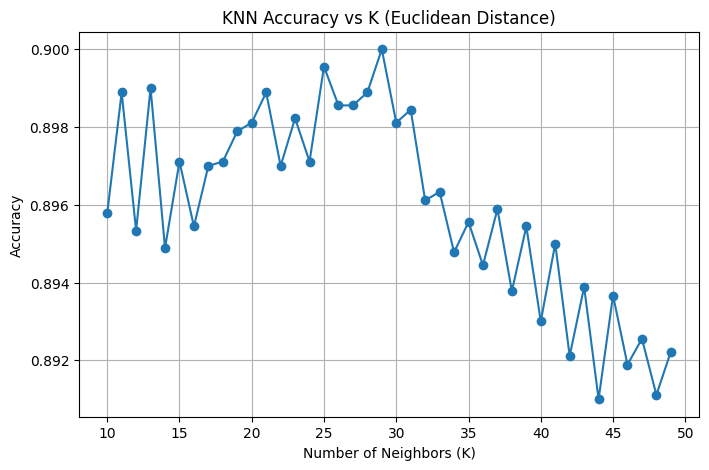

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K (Euclidean Distance)")
plt.grid(True)
plt.show()

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [67]:
# TODO: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

# evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)

Accuracy : 0.9274444444444444
Precision: 0.8917975567190227
Recall   : 0.7665


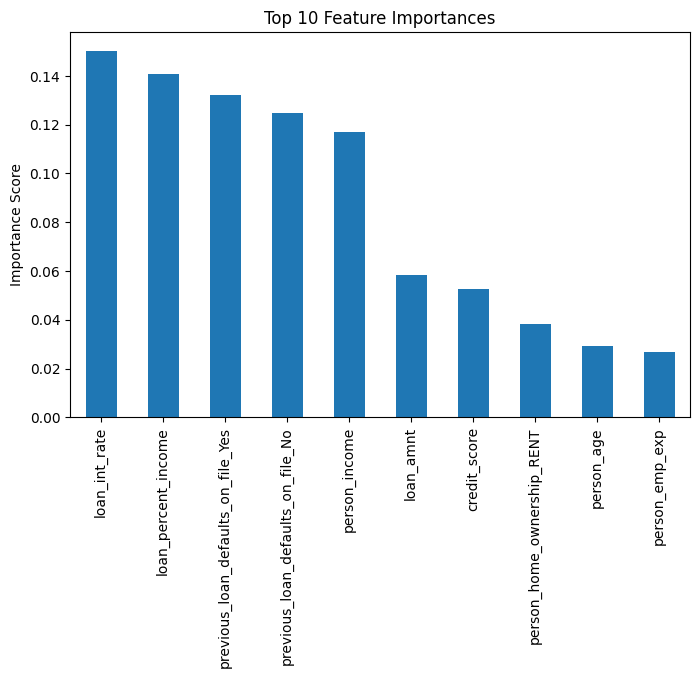

In [68]:
#Feature Importance
importances = pd.Series(
    rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(5)

#Visualisation
plt.figure(figsize=(8,5))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.show()

In [69]:
# # tuning using GS - taking too much time!
# #Key Hyperparameters
# param_grid={
#     "n_estimators": [50, 100,150],
#     "max_depth": [None, 5, 10, 15],
#     "min_samples_split": [2,3,5],
#     "max_features": ["sqrt", "log2"]
# }

# #GridSearchCV for Tuning
# rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="f1", n_jobs=-1)

# rf_grid.fit(X_train_scaled, y_train)

In [70]:
# #best outputs
# print("Best parameters found:")
# print(grid_rf.best_params_)

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here

- Best regression model: Polynomial regression with degree 2 performs slightly better in terms of RMSE and R², while RF achieves slightly lower MAE. both gives almost similar performance. Polynomial regression is better in this case because of its simplicity. SVR is the worst model in this case.

- Best classification model and why:  RF is best in terms of accuracy and precision. also, NB has the highest recall.

- One real-world deployment scenario: model trained on the insurance dataset can be used by health insurance companies to predict charges in cooperation with hospitals. also, the model trained on the loan dataset can be used by banks or other financial institutions to predict whether to give a customer a loan or not.


## Finish